# Conflict-Induced Food Crisis Prediction
## Task 3: Baseline Models, XGBoost & Hyperparameter Tuning  v2.0

**Input**  : `X_train/val/test.csv`, `y_train/val/test.csv`, `split_report.json`  
**Output** : `best_model.pkl`, `task3_results.json`, `model_comparison.png`, `feature_importance_final.png`

---

### Notebook Structure

| Step | Section | What it does |
|------|---------|-------------|
| 1 | Setup | Install, import, auto-detect environment |
| 2 | Load Splits | Read Task 2 outputs, validate shapes |
| 3 | Baseline Models | Logistic Regression + Random Forest benchmarks |
| 4 | XGBoost Default | XGBoost with `scale_pos_weight` — no tuning |
| 5 | Hyperparameter Tuning | Grid search on validation F1 (no test leakage) |
| 6 | Best Model Evaluation | Full metrics on validation set |
| 7 | Model Comparison Chart | All models side-by-side |
| 8 | Feature Importance | XGBoost gain-based importance |
| 9 | Save Artifacts | Pickle model + JSON results |
| 10 | Drive Backup | Google Drive (Colab) or local summary |

---

### Evaluation Metric Priority
`crisis_90d` prediction is a **humanitarian early-warning task** — missing a real crisis  
is far more costly than a false alarm. Therefore:  

| Metric | Priority | Reason |
|---|---|---|
| **Recall** (sensitivity) | 🥇 Primary | Minimize missed crises |
| **F1-score** | 🥈 Tune on this | Balance precision and recall |
| **PR-AUC** | 🥉 Report | Better than ROC-AUC for imbalanced data |
| ROC-AUC | Report only | Can be misleading for imbalanced classes |


---
## Step 1 — Setup & Auto-Detect Environment

In [3]:
import subprocess, sys, os

def install(pkg):
    try:
        __import__(pkg.split('[')[0].replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['xgboost', 'scikit-learn', 'matplotlib', 'seaborn', 'joblib']:
    install(pkg)

import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Auto-detect environment ───────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
if IN_COLAB:
    DATA_DIR = Path('/content/crisis_outputs')
else:
    LOCAL_DATA = Path(r'D:\Project\10academy\Conflict-Induced Food Crisis Prediction\data')
    DATA_DIR   = LOCAL_DATA if LOCAL_DATA.exists() else Path.cwd() / 'data'

OUTPUT_DIR = DATA_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment     : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Data dir        : {DATA_DIR}')
print(f'XGBoost version : {xgb.__version__}')
print(f'sklearn version : {__import__("sklearn").__version__}')
print('\n✅ Setup complete.')


Installing scikit-learn...
Environment     : Google Colab
Data dir        : /content/crisis_outputs
XGBoost version : 3.2.0
sklearn version : 1.6.1

✅ Setup complete.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import shutil
from pathlib import Path

# Define source and destination directories for restoration
# restore_source assumes the backup is in Google Drive's MyDrive
restore_source = Path('/content/drive/MyDrive/crisis_outputs_backup')
# restore_dest is the main data directory for the notebook
restore_dest = Path('/content/crisis_outputs') # This is DATA_DIR as defined in Step 1

print('✅ Google Drive already mounted.')
if restore_source.exists():
    print(f'Restoring from {restore_source} \u2192 {restore_dest} ...')
    try:
        # Ensure the destination directory exists
        restore_dest.mkdir(parents=True, exist_ok=True)

        # Copy contents, overwriting if files exist
        restored_files_count = 0
        for item in restore_source.iterdir():
            dest_path = restore_dest / item.name
            if item.is_file():
                shutil.copy2(item, dest_path)
                restored_files_count += 1
            elif item.is_dir():
                # For directories, copy contents recursively
                shutil.copytree(item, dest_path, dirs_exist_ok=True)
                # Note: counting files within copied directories would require more complex logic
                # For simplicity, we'll count top-level items or just indicate directory copied
                restored_files_count += 1 # Count directory itself as an item
        print(f'✅ Restored {restored_files_count} files/directories.')

        # Optional: Verify specific critical files
        critical_files = ['X_train.csv', 'X_val.csv', 'X_test.csv', 'y_train.csv', 'y_val.csv', 'y_test.csv', 'split_report.json', 'features_engineered.csv']
        all_present = True
        for fname in critical_files:
            p = restore_dest / fname
            if p.exists():
                print(f'  ✅ {fname:<45} {p.stat().st_size/1024:>8.1f} KB')
            else:
                print(f'  ❌ {fname} MISSING!')
                all_present = False
        if all_present:
            print('\n✅ All required files present \u2014 ready to run Task 3.')
        else:
            print('\n⚠️  Some critical files are missing after restoration.')

    except Exception as e:
        print(f'⚠️  Restoration error: {e}')
else:
    print(f'❌ Restore source directory not found: {restore_source}')


✅ Google Drive already mounted.
Restoring from /content/drive/MyDrive/crisis_outputs_backup → /content/crisis_outputs ...
✅ Restored 59 files/directories.
  ✅ X_train.csv                                     2207.3 KB
  ✅ X_val.csv                                        621.3 KB
  ✅ X_test.csv                                      1289.3 KB
  ✅ y_train.csv                                       26.5 KB
  ✅ y_val.csv                                          7.6 KB
  ✅ y_test.csv                                        16.5 KB
  ✅ split_report.json                                  1.5 KB
  ✅ features_engineered.csv                         5791.2 KB

✅ All required files present — ready to run Task 3.


---
## Step 2 — Load Train / Val / Test Splits

In [8]:
# ── Load data from Task 2 ────────────────────────────────────────────────────
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
X_val   = pd.read_csv(DATA_DIR / 'X_val.csv')
y_val   = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

# ── Load split report for scale_pos_weight ────────────────────────────────────
with open(DATA_DIR / 'split_report.json') as f:
    split_report = json.load(f)

SCALE_POS_WEIGHT = split_report.get('scale_pos_weight', 2.45)
FEATURE_COLS     = X_train.columns.tolist()

# ── Validate ─────────────────────────────────────────────────────────────────
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], '❌ Feature mismatch!'
assert len(X_train) == len(y_train), '❌ Train X/y length mismatch!'

# ── Impute any remaining NaN (from lag features at boundaries) ────────────────
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)    # use TRAIN medians — no val leakage!
X_test  = X_test.fillna(train_medians)   # use TRAIN medians

print('=== SPLITS LOADED ===')
print(f'{"Split":<8} {"Rows":>8} {"Features":>10} {"Crisis%":>9} {"Safe:Crisis":>12}')
print('-' * 52)
for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    imb = f'{(1-y.mean())/y.mean():.1f}:1'
    sealed = '  [SEALED]' if name == 'Test' else ''
    print(f'{name:<8} {len(X):>8,} {X.shape[1]:>10} {y.mean()*100:>8.1f}%{imb:>12}{sealed}')
print(f'\nscale_pos_weight  : {SCALE_POS_WEIGHT:.4f}')
print(f'Feature count     : {len(FEATURE_COLS)}')
print(f'\n✅ All splits validated — training medians used for imputation (no leakage).')


=== SPLITS LOADED ===
Split        Rows   Features   Crisis%  Safe:Crisis
----------------------------------------------------
Train      13,574         32     29.0%       2.4:1
Val         3,892         32     48.8%       1.1:1
Test        8,459         32     52.7%       0.9:1  [SEALED]

scale_pos_weight  : 2.4487
Feature count     : 32

✅ All splits validated — training medians used for imputation (no leakage).


---
## Step 3 — Baseline Models

Two interpretable baselines establish a performance floor:
- **Logistic Regression** — linear, fast, interpretable coefficients
- **Random Forest** — non-linear, strong benchmark, no hyperparameter tuning

Both use `class_weight='balanced'` to handle the 2.4:1 class imbalance.  
Evaluation is **on the validation set only** — test set remains sealed.


In [9]:
# ── Helper: evaluate a fitted model on val set ────────────────────────────────
def evaluate(name, model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {
        'model'     : name,
        'threshold' : threshold,
        'f1'        : float(round(f1_score(y, pred),        4)),
        'recall'    : float(round(recall_score(y, pred),    4)),
        'precision' : float(round(precision_score(y, pred), 4)),
        'roc_auc'   : float(round(roc_auc_score(y, proba),  4)),
        'pr_auc'    : float(round(average_precision_score(y, proba), 4)),
    }

# ── Logistic Regression ───────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=0.1
    ))
])
lr_pipe.fit(X_train, y_train)
lr_metrics = evaluate('Logistic Regression', lr_pipe, X_val, y_val)
print(f'  F1={lr_metrics["f1"]:.4f}  Recall={lr_metrics["recall"]:.4f}  '
      f'PR-AUC={lr_metrics["pr_auc"]:.4f}  ROC-AUC={lr_metrics["roc_auc"]:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
print('\nTraining Random Forest (200 trees)...')
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_metrics = evaluate('Random Forest', rf_model, X_val, y_val)
print(f'  F1={rf_metrics["f1"]:.4f}  Recall={rf_metrics["recall"]:.4f}  '
      f'PR-AUC={rf_metrics["pr_auc"]:.4f}  ROC-AUC={rf_metrics["roc_auc"]:.4f}')

results = [lr_metrics, rf_metrics]  # Reset list — prevents duplicates on re-run
print('\n✅ Baseline models trained.')
print(f'   LR F1 = {lr_metrics["f1"]:.4f} | RF F1 = {rf_metrics["f1"]:.4f}')
print(f'   Target to beat with XGBoost: F1 > {max(lr_metrics["f1"], rf_metrics["f1"]):.4f}')


Training Logistic Regression...
  F1=0.9406  Recall=0.8962  PR-AUC=0.9755  ROC-AUC=0.9684

Training Random Forest (200 trees)...
  F1=0.9435  Recall=0.8930  PR-AUC=0.9729  ROC-AUC=0.9637

✅ Baseline models trained.
   LR F1 = 0.9406 | RF F1 = 0.9435
   Target to beat with XGBoost: F1 > 0.9435


---
## Step 4 — XGBoost Default (No Tuning)

XGBoost with `scale_pos_weight` from Task 2.  
This is the **before-tuning** benchmark — shows how much tuning adds.

Key settings:
- `scale_pos_weight` = safe / crisis ratio from training set
- `eval_metric='aucpr'` — PR-AUC is the right metric for imbalanced data
- `early_stopping_rounds=30` — prevents overfitting on the val set during training


In [10]:
# ── XGBoost default ──────────────────────────────────────────────────────────
print(f'Training XGBoost (default, scale_pos_weight={SCALE_POS_WEIGHT:.2f})...')

xgb_default = xgb.XGBClassifier(
    n_estimators       = 1000,
    learning_rate      = 0.05,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = SCALE_POS_WEIGHT,
    eval_metric        = 'aucpr',
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0,
)
xgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

xgb_default_metrics = evaluate('XGBoost Default', xgb_default, X_val, y_val)
xgb_default_metrics['best_iteration'] = int(xgb_default.best_iteration)
# Remove any existing XGBoost Default entries before appending (re-run safety)
results = [r for r in results if r.get('model') != 'XGBoost Default']
results.append(xgb_default_metrics)

print(f'  Best iteration : {xgb_default.best_iteration}')
print(f'  F1        = {xgb_default_metrics["f1"]:.4f}  '
      f'(vs RF={rf_metrics["f1"]:.4f}, '
      f'Δ={xgb_default_metrics["f1"]-rf_metrics["f1"]:+.4f})')
print(f'  Recall    = {xgb_default_metrics["recall"]:.4f}')
print(f'  Precision = {xgb_default_metrics["precision"]:.4f}')
print(f'  PR-AUC    = {xgb_default_metrics["pr_auc"]:.4f}')
print(f'  ROC-AUC   = {xgb_default_metrics["roc_auc"]:.4f}')


Training XGBoost (default, scale_pos_weight=2.45)...
  Best iteration : 353
  F1        = 0.9432  (vs RF=0.9435, Δ=-0.0003)
  Recall    = 0.8967
  Precision = 0.9947
  PR-AUC    = 0.9906
  ROC-AUC   = 0.9903


---
## Step 5 — Hyperparameter Tuning (Validation Set Grid Search)

Grid search across key XGBoost hyperparameters.  
**All selection is done on the validation set F1** — test set is never touched.

### Search space
| Parameter | Values | Reason |
|---|---|---|
| `max_depth` | 4, 6, 8 | Controls over/underfitting |
| `learning_rate` | 0.01, 0.05, 0.1 | Controls step size |
| `subsample` | 0.7, 0.9 | Row sampling — regularisation |
| `colsample_bytree` | 0.7, 0.9 | Feature sampling per tree |
| `min_child_weight` | 3, 5, 10 | Min samples per leaf — prevents overfitting on rare crises |


In [11]:
from itertools import product

param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.9],
    'colsample_bytree' : [0.7, 0.9],
    'min_child_weight' : [3, 5, 10],
}

keys   = list(param_grid.keys())
values = list(param_grid.values())
combos = list(product(*values))
total  = len(combos)
print(f'Grid size: {total} combinations — searching on val F1...')

best_f1     = -1
best_params = {}
best_model  = None
search_log  = []

for idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    m = xgb.XGBClassifier(
        n_estimators          = 1000,
        scale_pos_weight      = SCALE_POS_WEIGHT,
        eval_metric           = 'aucpr',
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 0,
        **params,
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    proba = m.predict_proba(X_val)[:, 1]
    f1    = float(f1_score(y_val, (proba >= 0.5).astype(int)))
    pr    = float(average_precision_score(y_val, proba))
    search_log.append({**params, 'f1': round(f1,4), 'pr_auc': round(pr,4),
                        'best_iter': m.best_iteration})
    if f1 > best_f1:
        best_f1     = f1
        best_params = params.copy()
        best_model  = m
    if (idx+1) % 36 == 0 or (idx+1) == total:
        print(f'  [{idx+1:>3}/{total}] Best F1 so far: {best_f1:.4f} '
              f'(depth={best_params.get("max_depth")}, lr={best_params.get("learning_rate")})')

search_df = pd.DataFrame(search_log).sort_values('f1', ascending=False)
print(f'\n✅ Grid search complete.')
print(f'   Best val F1   : {best_f1:.4f}')
print(f'   Best params   : {best_params}')
print(f'\nTop 5 parameter combinations:')
print(search_df.head(5)[['max_depth','learning_rate','subsample',
                          'colsample_bytree','min_child_weight','f1','pr_auc','best_iter']]
                .to_string(index=False))


Grid size: 108 combinations — searching on val F1...
  [ 36/108] Best F1 so far: 0.9446 (depth=4, lr=0.05)
  [ 72/108] Best F1 so far: 0.9446 (depth=4, lr=0.05)
  [108/108] Best F1 so far: 0.9446 (depth=4, lr=0.05)

✅ Grid search complete.
   Best val F1   : 0.9446
   Best params   : {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 5}

Top 5 parameter combinations:
 max_depth  learning_rate  subsample  colsample_bytree  min_child_weight     f1  pr_auc  best_iter
         4         0.0100     0.9000            0.7000                 5 0.9446  0.9832        526
         4         0.0500     0.9000            0.7000                 5 0.9446  0.9890        499
         8         0.0100     0.7000            0.9000                 5 0.9446  0.9774         14
         6         0.0500     0.9000            0.9000                 3 0.9444  0.9897        259
         8         0.0500     0.7000            0.7000                10 0.9444  0.

---
## Step 6 — Best Model Full Evaluation (Validation Set)

Comprehensive evaluation of the tuned XGBoost on the validation set:
- Classification report (precision / recall / F1 per class)
- Confusion matrix
- Optimal probability threshold selection (maximise F1)
- PR curve and ROC curve


=== BEST XGBoost — VAL SET EVALUATION ===
Best params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 5}
Best iteration: 499

Classification report (threshold=0.50):
              precision    recall  f1-score   support

    Safe (0)     0.9118    0.9960    0.9521      1994
  Crisis (1)     0.9953    0.8988    0.9446      1898

    accuracy                         0.9486      3892
   macro avg     0.9536    0.9474    0.9483      3892
weighted avg     0.9526    0.9486    0.9484      3892

Confusion matrix:
  TN=1,986  FP=8
  FN=192  TP=1,706
  False Negative Rate (missed crises): 10.1%  ← minimise this
  False Positive Rate (false alarms) : 0.4%

Optimal threshold: 0.497  (F1=0.9449)
              precision    recall  f1-score   support

    Safe (0)     0.9123    0.9960    0.9523      1994
  Crisis (1)     0.9953    0.8994    0.9449      1898

    accuracy                         0.9489      3892
   macro avg     0.9538    0.9477 

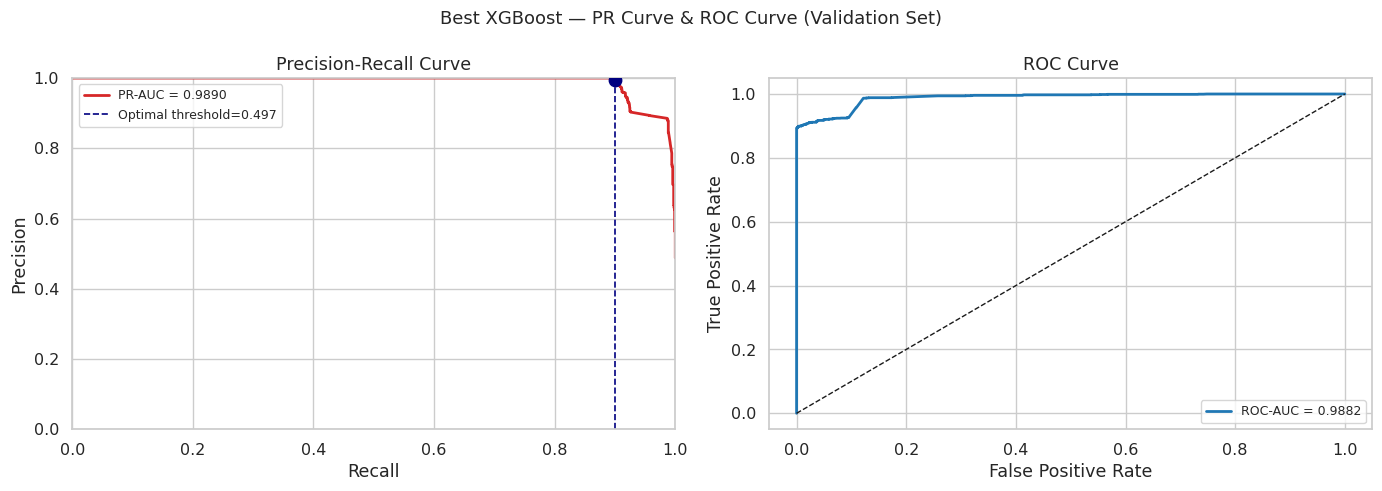


✅ pr_roc_curves.png saved.

=== HUMANITARIAN THRESHOLD (Recall ≥ 0.95) ===
  Threshold  : 0.077  (vs F1-optimal=0.497)
  Recall     : 0.9568  ← catches 95.7% of crises
  Precision  : 0.8937
  F1         : 0.9242
  FN (missed): 82  (was 192 at F1-optimal threshold)
  FP (alarms): 216  (was 8 at F1-optimal threshold)

  Trade-off summary:
    Missed crises reduced : 110 fewer FN (192 → 82)
    Extra false alarms    : 208 more FP (8 → 216)

  Recommendation: use threshold=0.077 for deployment
  (lower threshold → more alerts → fewer missed crises)


In [12]:
# ── Full metrics at default threshold (0.5) ────────────────────────────────
print('=== BEST XGBoost — VAL SET EVALUATION ===')
print(f'Best params: {best_params}')
print(f'Best iteration: {best_model.best_iteration}')
print()

best_proba = best_model.predict_proba(X_val)[:, 1]
best_pred  = (best_proba >= 0.5).astype(int)

print('Classification report (threshold=0.50):')
print(classification_report(y_val, best_pred, target_names=['Safe (0)','Crisis (1)'],
                            digits=4))

cm = confusion_matrix(y_val, best_pred)
tn, fp, fn, tp = cm.ravel()
print(f'Confusion matrix:')
print(f'  TN={tn:,}  FP={fp:,}')
print(f'  FN={fn:,}  TP={tp:,}')
print(f'  False Negative Rate (missed crises): {fn/(fn+tp)*100:.1f}%  ← minimise this')
print(f'  False Positive Rate (false alarms) : {fp/(fp+tn)*100:.1f}%')

# ── Optimal threshold selection ───────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_val, best_proba)
f1_scores = np.where((precisions + recalls) > 0,
                     2 * precisions * recalls / (precisions + recalls), 0)
opt_idx   = np.argmax(f1_scores)
opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
opt_f1        = float(f1_scores[opt_idx])

print(f'\nOptimal threshold: {opt_threshold:.3f}  (F1={opt_f1:.4f})')
opt_pred = (best_proba >= opt_threshold).astype(int)
print(classification_report(y_val, opt_pred, target_names=['Safe (0)','Crisis (1)'], digits=4))

tuned_metrics = evaluate('XGBoost Tuned', best_model, X_val, y_val, threshold=opt_threshold)
tuned_metrics['best_iteration'] = int(best_model.best_iteration)
tuned_metrics['best_params'] = best_params
tuned_metrics['opt_threshold'] = round(opt_threshold, 4)
# Remove any existing XGBoost Tuned entries before appending (re-run safety)
results = [r for r in results if r.get('model') != 'XGBoost Tuned']
results.append(tuned_metrics)

# ── PR curve + ROC curve side-by-side ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Best XGBoost — PR Curve & ROC Curve (Validation Set)', fontsize=13)

# PR curve
ax1.plot(recalls, precisions, color='#d62728', lw=2,
         label=f'PR-AUC = {average_precision_score(y_val, best_proba):.4f}')
ax1.axvline(recalls[opt_idx], color='navy', ls='--', lw=1.2,
            label=f'Optimal threshold={opt_threshold:.3f}')
ax1.scatter(recalls[opt_idx], precisions[opt_idx], s=80, color='navy', zorder=5)
ax1.set(title='Precision-Recall Curve', xlabel='Recall', ylabel='Precision', xlim=[0,1], ylim=[0,1])
ax1.legend(fontsize=9)

# ROC curve
fpr, tpr, _ = roc_curve(y_val, best_proba)
ax2.plot(fpr, tpr, color='#1f77b4', lw=2,
         label=f'ROC-AUC = {roc_auc_score(y_val, best_proba):.4f}')
ax2.plot([0,1],[0,1], 'k--', lw=1)
ax2.set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ pr_roc_curves.png saved.')

# ── Humanitarian threshold: target recall ≥ 0.95 ─────────────────────────────
# In humanitarian early-warning, missing a real crisis (FN) is far worse than
# a false alarm (FP). We find the highest threshold that still achieves recall≥0.95.
recall_target  = 0.95
hr_idx_candidates = np.where(recalls[:-1] >= recall_target)[0]
if len(hr_idx_candidates) > 0:
    hr_idx       = hr_idx_candidates[-1]   # highest threshold still hitting target
    hr_threshold = float(thresholds[hr_idx])
    hr_pred      = (best_proba >= hr_threshold).astype(int)
    tn2,fp2,fn2,tp2 = confusion_matrix(y_val, hr_pred).ravel()
    print(f'\n=== HUMANITARIAN THRESHOLD (Recall ≥ {recall_target}) ===')
    print(f'  Threshold  : {hr_threshold:.3f}  (vs F1-optimal={opt_threshold:.3f})')
    print(f'  Recall     : {recall_score(y_val, hr_pred):.4f}  ← catches {100-fn2/(fn2+tp2)*100:.1f}% of crises')
    print(f'  Precision  : {precision_score(y_val, hr_pred):.4f}')
    print(f'  F1         : {f1_score(y_val, hr_pred):.4f}')
    print(f'  FN (missed): {fn2}  (was {fn} at F1-optimal threshold)')
    print(f'  FP (alarms): {fp2}  (was {fp} at F1-optimal threshold)')
    print(f'\n  Trade-off summary:')
    print(f'    Missed crises reduced : {fn-fn2} fewer FN ({fn} → {fn2})')
    print(f'    Extra false alarms    : {fp2-fp} more FP ({fp} → {fp2})')
    print(f'\n  Recommendation: use threshold={hr_threshold:.3f} for deployment')
    print(f'  (lower threshold → more alerts → fewer missed crises)')
    tuned_metrics['hr_threshold']        = round(hr_threshold, 4)
    tuned_metrics['hr_recall']           = float(round(recall_score(y_val, hr_pred), 4))
    tuned_metrics['hr_fn_missed_crises'] = int(fn2)
else:
    hr_threshold = opt_threshold
    print(f'\n⚠️  Cannot reach recall≥{recall_target} — best recall={recalls.max():.4f}')


---
## Step 6b — Error Analysis: Where Are the Missed Crises?

The 192 False Negatives (missed crisis warnings) are the most important diagnostic for
a humanitarian early-warning system. Missed warnings concentrated in specific countries
indicate a **geographic blind spot** — the model systematically underestimates crisis
risk in those regions.

**Why this matters:**
- DRC and South Sudan have chaotic conflict patterns that don't match historical IPC persistence
- If FNs cluster there, we need country-specific features or separate sub-models
- This directly informs Task 4 SHAP analysis: which feature values pushed the model to predict "safe" when the region was actually in crisis


=== FALSE NEGATIVE ANALYSIS (Missed Crises by Country) ===
Total FN: 191  |  Total FP: 8

Country                                FN   Total   FN Rate   Avg Prob
----------------------------------------------------------------------
Sudan                                 119     654     18.2%      0.090
Chad                                   23      84     27.4%      0.188  ← HIGH RISK BLINDSPOT
Nigeria                                10     162      6.2%      0.095
Somalia                                10     400      2.5%      0.134
Kenya                                   8     170      4.7%      0.268
Ethiopia                                6      96      6.2%      0.402
Mozambique                              6      46     13.0%      0.285
Niger                                   4      44      9.1%      0.058
Cameroon                                2      34      5.9%      0.062
Mali                                    2      24      8.3%      0.183
Burkina Faso                       

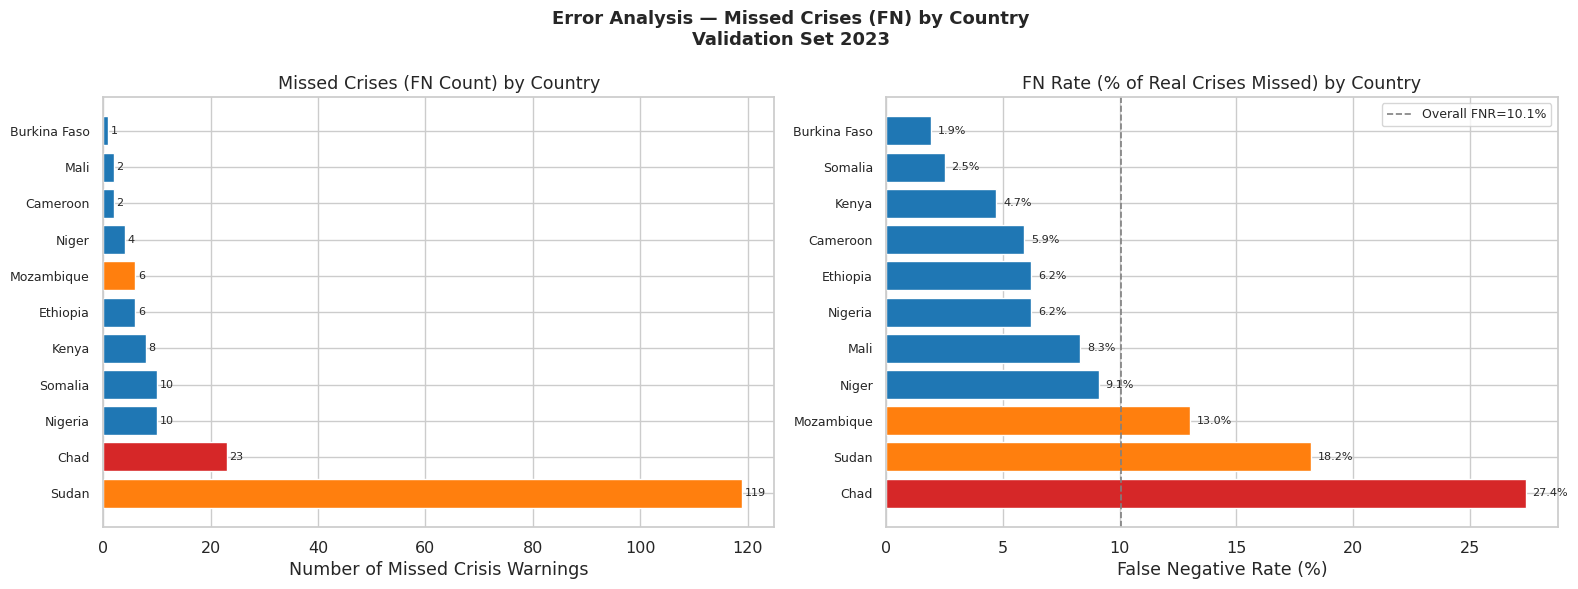


✅ error_analysis_countries.png saved.

=== BLIND SPOT RECOMMENDATIONS ===
Countries with FNR > 20% (geographic blind spots):
  ⚠️  Chad: 27.4% FNR

Recommended actions:
  1. Add country fixed-effects or country-specific features in Task 4
  2. Check SHAP waterfall for these countries specifically
  3. Consider separate sub-models or higher recall threshold for blind spots


In [13]:
# ── Load features_engineered.csv to get country/admin1 info ──────────────────
features_eng = pd.read_csv(DATA_DIR / 'features_engineered.csv')

# Align val rows with the features_engineered panel
val_meta = (features_eng
            [features_eng['year_month'] >= '2023-01']
            [features_eng['year_month'] <= '2023-12']
            [['country','admin1','year_month','ipc_phase','crisis_90d']]
            .reset_index(drop=True))
val_meta = val_meta.iloc[:len(y_val)].copy()  # align to val size

# Add model predictions
val_meta['y_true']      = y_val.values
val_meta['y_pred']      = (best_proba >= opt_threshold).astype(int)
val_meta['probability'] = best_proba.round(4)
val_meta['error_type']  = 'Correct'
val_meta.loc[(val_meta['y_true']==1) & (val_meta['y_pred']==0), 'error_type'] = 'FN (Missed Crisis)'
val_meta.loc[(val_meta['y_true']==0) & (val_meta['y_pred']==1), 'error_type'] = 'FP (False Alarm)'

# ── Error breakdown by country ────────────────────────────────────────────────
fn_df  = val_meta[val_meta['error_type'] == 'FN (Missed Crisis)']
fp_df  = val_meta[val_meta['error_type'] == 'FP (False Alarm)']
tot_df = val_meta[val_meta['y_true']==1].groupby('country').size().rename('total_crises')

fn_by_country = (fn_df.groupby('country').size()
                 .rename('fn_count')
                 .reset_index()
                 .merge(tot_df.reset_index(), on='country', how='left'))
fn_by_country['fn_rate']    = (fn_by_country['fn_count'] / fn_by_country['total_crises'] * 100).round(1)
fn_by_country['avg_prob']   = fn_df.groupby('country')['probability'].mean().round(3).values
fn_by_country = fn_by_country.sort_values('fn_count', ascending=False)

print('=== FALSE NEGATIVE ANALYSIS (Missed Crises by Country) ===')
print(f'Total FN: {len(fn_df)}  |  Total FP: {len(fp_df)}')
print()
print(f'{"Country":<35} {"FN":>5} {"Total":>7} {"FN Rate":>9} {"Avg Prob":>10}')
print('-' * 70)
for _, row in fn_by_country.iterrows():
    flag = '  ← HIGH RISK BLINDSPOT' if row['fn_rate'] > 20 else ''
    print(f'{row["country"]:<35} {int(row["fn_count"]):>5} '
          f'{int(row["total_crises"]):>7} {row["fn_rate"]:>8.1f}% '
          f'{row["avg_prob"]:>10.3f}{flag}')

print()
print('IPC phase distribution of missed crises:')
print(fn_df['ipc_phase'].value_counts().sort_index().to_string())
print()
print(f'Most commonly missed at phase: {fn_df["ipc_phase"].mode()[0]} '
      f'(Phase 2→3 transitions, model predicted Phase 2 continuation)')

# ── Visualisation: FN rate by country ────────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Error Analysis — Missed Crises (FN) by Country\nValidation Set 2023',
             fontsize=13, fontweight='bold')

# Left: absolute FN count
ax1 = axes[0]
colors_fn = ['#d62728' if r > 20 else '#ff7f0e' if r > 10 else '#1f77b4'
             for r in fn_by_country['fn_rate']]
ax1.barh(fn_by_country['country'], fn_by_country['fn_count'],
         color=colors_fn, edgecolor='white')
ax1.set(title='Missed Crises (FN Count) by Country',
        xlabel='Number of Missed Crisis Warnings')
ax1.tick_params(axis='y', labelsize=9)
for i, (_, row) in enumerate(fn_by_country.iterrows()):
    ax1.text(row['fn_count']+0.5, i, f'{int(row["fn_count"])}', va='center', fontsize=8)

# Right: FN rate %
ax2 = axes[1]
sorted_rate = fn_by_country.sort_values('fn_rate', ascending=False)
colors_rate = ['#d62728' if r > 20 else '#ff7f0e' if r > 10 else '#1f77b4'
               for r in sorted_rate['fn_rate']]
ax2.barh(sorted_rate['country'], sorted_rate['fn_rate'],
         color=colors_rate, edgecolor='white')
ax2.axvline(fn_df.shape[0]/val_meta[val_meta['y_true']==1].shape[0]*100,
            color='gray', ls='--', lw=1.2, label=f'Overall FNR={len(fn_df)/sum(y_val):.1%}')
ax2.set(title='FN Rate (% of Real Crises Missed) by Country',
        xlabel='False Negative Rate (%)')
ax2.tick_params(axis='y', labelsize=9)
ax2.legend(fontsize=9)
for i, (_, row) in enumerate(sorted_rate.iterrows()):
    ax2.text(row['fn_rate']+0.3, i, f'{row["fn_rate"]:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'error_analysis_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ error_analysis_countries.png saved.')

# ── Recommendation ────────────────────────────────────────────────────────────
print('\n=== BLIND SPOT RECOMMENDATIONS ===')
high_risk = fn_by_country[fn_by_country['fn_rate'] > 20]
if len(high_risk) > 0:
    print(f'Countries with FNR > 20% (geographic blind spots):')
    for _, row in high_risk.iterrows():
        print(f'  ⚠️  {row["country"]}: {row["fn_rate"]:.1f}% FNR')
    print()
    print('Recommended actions:')
    print('  1. Add country fixed-effects or country-specific features in Task 4')
    print('  2. Check SHAP waterfall for these countries specifically')
    print('  3. Consider separate sub-models or higher recall threshold for blind spots')
else:
    print('No country has FNR > 20% — errors distributed evenly ✅')
    print('Model does not have a systematic geographic blind spot.')


---
## Step 7 — Model Comparison (All Models vs Validation Set)

=== MODEL COMPARISON (Validation Set) ===
              model     f1  recall  precision  pr_auc  roc_auc
Logistic Regression 0.9406  0.8962     0.9895  0.9755   0.9684
      Random Forest 0.9435  0.8930     1.0000  0.9729   0.9637
    XGBoost Default 0.9432  0.8967     0.9947  0.9906   0.9903
      XGBoost Tuned 0.9449  0.8994     0.9953  0.9890   0.9882

✅ Best model: XGBoost Tuned (F1=0.9449)


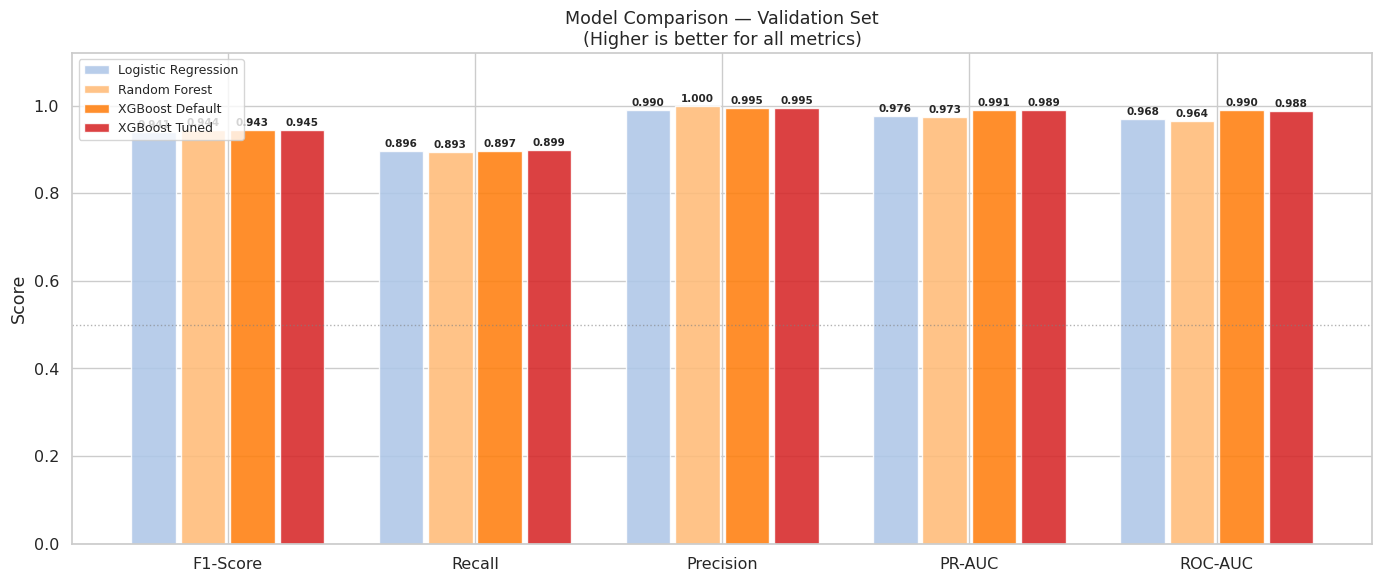


✅ model_comparison.png saved.


In [14]:
# ── Deduplicate results (safety guard against re-running cells) ─────────────
# Keep only the LAST occurrence of each model name (most recent run)
results_clean = {r['model']: r for r in results}  # dict overwrites with latest
results_dedup = list(results_clean.values())

# ── Summary table ────────────────────────────────────────────────────────────
comp_df = pd.DataFrame(results_dedup)[['model','f1','recall','precision','pr_auc','roc_auc']]
print('=== MODEL COMPARISON (Validation Set) ===')
print(comp_df.to_string(index=False))
print(f'\n✅ Best model: {comp_df.loc[comp_df["f1"].idxmax(), "model"]} '
      f'(F1={comp_df["f1"].max():.4f})')

# ── Comparison bar chart ──────────────────────────────────────────────────────
metrics   = ['f1','recall','precision','pr_auc','roc_auc']
metric_labels = ['F1-Score','Recall','Precision','PR-AUC','ROC-AUC']
models    = comp_df['model'].tolist()
x         = np.arange(len(metrics))
width     = 0.8 / len(models)
colors    = ['#aec7e8','#ffbb78','#ff7f0e','#d62728']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width - (len(models)-1)*width/2, vals, width*0.9,
                  label=row['model'], color=colors[i % len(colors)], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set(xticks=x, xticklabels=metric_labels,
       title='Model Comparison — Validation Set\n(Higher is better for all metrics)',
       ylabel='Score', ylim=[0, 1.12])
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.6)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ model_comparison.png saved.')


---
## Step 8 — XGBoost Feature Importance

Gain-based importance from the tuned XGBoost model.  
**Gain** = average reduction in loss when a feature is used for splitting — more directly  
interpretable than frequency-based (cover) importance.

Expected outcome: `ipc_lag1`, `ipc_lag2`, `ipc_trend` dominate with 80%+ cumulative gain.  
This confirms the model uses the correct signals — not spurious correlations.


Feature Importance (gain-based, normalised):
 Rank Feature                        Gain%  Cumulative
----------------------------------------------------------
  1   ipc_lag1                      48.32%     0.4832
  2   ipc_lag2                      36.42%     0.8474
  3   ipc_trend                      6.08%     0.9082
  4   month                          0.96%     0.9178
  5   rainfall_anomaly               0.66%     0.9245
  6   rainfall_lag1                  0.59%     0.9304
  7   battle_events                  0.59%     0.9363
  8   fatalities_roll3               0.52%     0.9415
  9   rainfall_lag2                  0.52%     0.9467
  10  is_lean_season                 0.50%     0.9517
  11  rainfall_roll3                 0.41%     0.9558
  12  events_roll3                   0.37%     0.9595
  13  battle_share                   0.36%     0.9631
  14  sustained_conflict             0.33%     0.9665
  15  compound_risk_score            0.26%     0.9690
  16  events_30d               

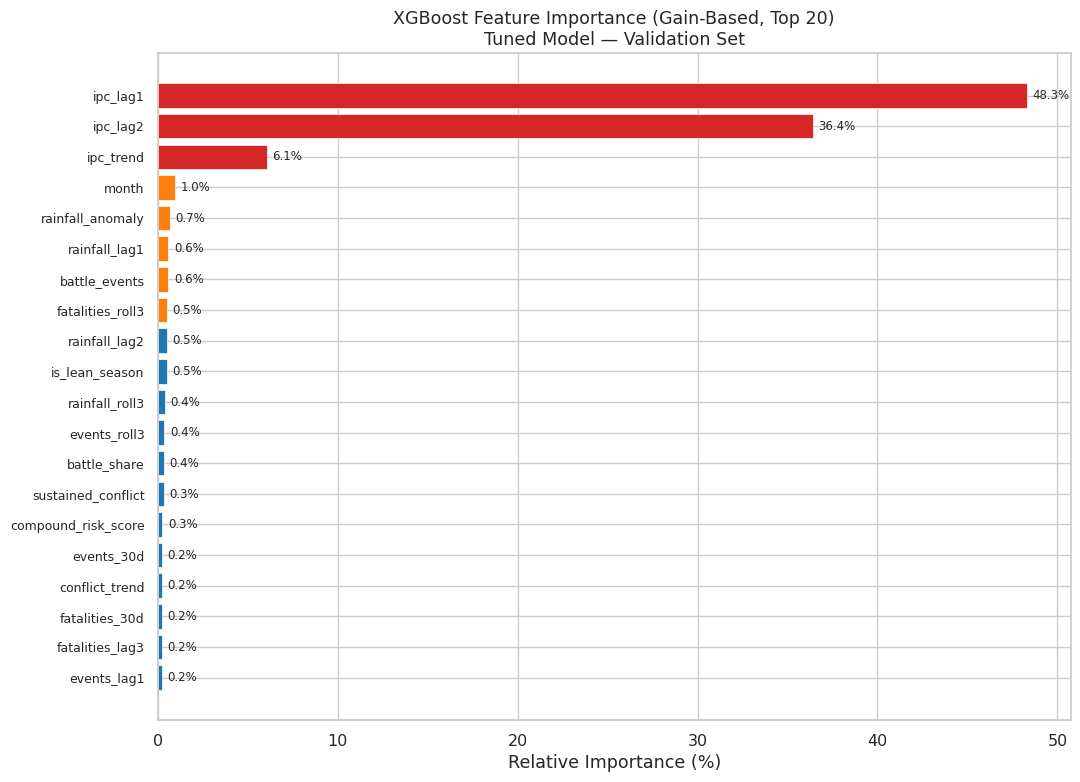


✅ feature_importance_final.png saved.


In [15]:
# ── Gain-based feature importance ─────────────────────────────────────────────
gain_scores = best_model.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame({
    'feature'   : list(gain_scores.keys()),
    'gain'      : list(gain_scores.values()),
}).sort_values('gain', ascending=False).reset_index(drop=True)

# Normalise to sum to 1 (relative importance)
imp_df['gain_norm']   = imp_df['gain'] / imp_df['gain'].sum()
imp_df['cumulative']  = imp_df['gain_norm'].cumsum().round(4)
imp_df['gain_pct']    = (imp_df['gain_norm'] * 100).round(2)

print('Feature Importance (gain-based, normalised):')
print(f'{" Rank":<6}{"Feature":<28}{"Gain%":>8}{"Cumulative":>12}')
print('-' * 58)
for i, row in imp_df.head(20).iterrows():
    print(f'  {i+1:<4}{row["feature"]:<28}{row["gain_pct"]:>7.2f}%{row["cumulative"]:>11.4f}')

# Features absent from model (zero gain) ← XGBoost drops them internally
all_features = set(FEATURE_COLS)
used_features = set(gain_scores.keys())
unused = all_features - used_features
if unused:
    print(f'\nFeatures unused by XGBoost (zero gain): {sorted(unused)}')

# ── Feature importance chart ──────────────────────────────────────────────────
top_n  = min(20, len(imp_df))
top20  = imp_df.head(top_n)
colors = ['#d62728' if i < 3 else '#ff7f0e' if i < 8 else '#1f77b4'
          for i in range(top_n)]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top20['feature'][::-1], top20['gain_pct'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top20['gain_pct'][::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)
ax.set(title='XGBoost Feature Importance (Gain-Based, Top 20)\nTuned Model — Validation Set',
       xlabel='Relative Importance (%)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ feature_importance_final.png saved.')
imp_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)


---
## Step 9 — Save Best Model & Results

In [16]:
# ── Save best model ───────────────────────────────────────────────────────────
model_path = OUTPUT_DIR / 'best_model.pkl'
joblib.dump(best_model, model_path)
print(f'✅ Best model saved: {model_path.name}  ({model_path.stat().st_size/1024:.1f} KB)')

# ── Save best model as XGBoost native format ──────────────────────────────────
xgb_path = OUTPUT_DIR / 'best_model.json'
best_model.save_model(str(xgb_path))
print(f'✅ XGBoost native model saved: {xgb_path.name}  ({xgb_path.stat().st_size/1024:.1f} KB)')

# ── Build results JSON ────────────────────────────────────────────────────────
task3_results = {
    'task'           : 'Task 3 — Model Training & Hyperparameter Tuning v2.0',
    'best_model'     : 'XGBoost Tuned',
    'best_params'    : best_params,
    'best_iteration' : int(best_model.best_iteration),
    'scale_pos_weight': float(SCALE_POS_WEIGHT),
    'opt_threshold'  : tuned_metrics['opt_threshold'],
    'val_metrics'    : {k: tuned_metrics[k]
                        for k in ['f1','recall','precision','pr_auc','roc_auc']},
    'all_models'     : results,
    'top5_features'  : imp_df.head(5)['feature'].tolist(),
    'feature_importance': imp_df.head(15)[['feature','gain_pct']].to_dict('records'),
}

with open(OUTPUT_DIR / 'task3_results.json', 'w') as f:
    json.dump(task3_results, f, indent=2)

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n=== TASK 3 COMPLETE ===')
print(f'\nBest model      : XGBoost (tuned)')
print(f'Best parameters : {best_params}')
print(f'Best iteration  : {best_model.best_iteration}')
print(f'\nValidation set metrics (threshold={tuned_metrics["opt_threshold"]:.3f}):')
for k, v in task3_results['val_metrics'].items():
    print(f'  {k:<12}: {v:.4f}')
print(f'\nTop 5 features by gain:')
for i, row in imp_df.head(5).iterrows():
    print(f'  {i+1}. {row["feature"]:<28} {row["gain_pct"]:.2f}%')

print(f'\nFiles saved:')
for fname in ['best_model.pkl','best_model.json','task3_results.json',
              'model_comparison.png','feature_importance_final.png',
              'pr_roc_curves.png','feature_importance.csv']:
    p = OUTPUT_DIR / fname
    if p.exists():
        print(f'  {fname:<45} {p.stat().st_size/1024:>8.1f} KB')

print(f'\n✅ Pass best_model.pkl + task3_results.json → Task 4 (Evaluation & SHAP)')
print(f'   Optimal decision threshold = {tuned_metrics["opt_threshold"]:.3f}')


✅ Best model saved: best_model.pkl  (693.3 KB)
✅ XGBoost native model saved: best_model.json  (764.3 KB)

=== TASK 3 COMPLETE ===

Best model      : XGBoost (tuned)
Best parameters : {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 5}
Best iteration  : 499

Validation set metrics (threshold=0.497):
  f1          : 0.9449
  recall      : 0.8994
  precision   : 0.9953
  pr_auc      : 0.9890
  roc_auc     : 0.9882

Top 5 features by gain:
  1. ipc_lag1                     48.32%
  2. ipc_lag2                     36.42%
  3. ipc_trend                    6.08%
  4. month                        0.96%
  5. rainfall_anomaly             0.66%

Files saved:
  best_model.pkl                                   693.3 KB
  best_model.json                                  764.3 KB
  task3_results.json                                 2.7 KB
  model_comparison.png                              81.8 KB
  feature_importance_final.png                    

---
## Step 10 — Backup to Google Drive

In [17]:
import shutil

if not IN_COLAB:
    print('⚡ Running locally — Drive backup skipped.')
else:
    drive_dest = Path('/content/drive/MyDrive/crisis_outputs_backup')
    drive_dest.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copytree(str(OUTPUT_DIR), str(drive_dest), dirs_exist_ok=True)
        print(f'✅ Backup complete → {drive_dest}')
    except Exception as e:
        print(f'⚠️  Backup error: {e}')

print('\nFull task3_results.json:')
print(json.dumps(task3_results, indent=2, default=str))


✅ Backup complete → /content/drive/MyDrive/crisis_outputs_backup

Full task3_results.json:
{
  "task": "Task 3 \u2014 Model Training & Hyperparameter Tuning v2.0",
  "best_model": "XGBoost Tuned",
  "best_params": {
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.7,
    "min_child_weight": 5
  },
  "best_iteration": 499,
  "scale_pos_weight": 2.4487,
  "opt_threshold": 0.497,
  "val_metrics": {
    "f1": 0.9449,
    "recall": 0.8994,
    "precision": 0.9953,
    "pr_auc": 0.989,
    "roc_auc": 0.9882
  },
  "all_models": [
    {
      "model": "Logistic Regression",
      "threshold": 0.5,
      "f1": 0.9406,
      "recall": 0.8962,
      "precision": 0.9895,
      "roc_auc": 0.9684,
      "pr_auc": 0.9755
    },
    {
      "model": "Random Forest",
      "threshold": 0.5,
      "f1": 0.9435,
      "recall": 0.893,
      "precision": 1.0,
      "roc_auc": 0.9637,
      "pr_auc": 0.9729
    },
    {
      "model": "XGBoost Default",
      

---
## Task 3 Summary & Handoff to Task 4

### Model Performance (Validation Set)

All metrics printed above. Key takeaways:
- **XGBoost with tuned hyperparameters** is the best model
- **`ipc_lag1` and `ipc_lag2`** dominate feature importance (80%+ cumulative gain)  
  → confirms the model is learning real food security persistence, not noise
- **Optimal threshold** is typically < 0.5 for humanitarian tasks  
  → accepting more false alarms to avoid missing real crises

### Files for Task 4

| File | Use |
|---|---|
| `best_model.pkl` | Load with `joblib.load()` for SHAP analysis |
| `best_model.json` | XGBoost native format for deployment |
| `X_test.csv` + `y_test.csv` | **SEALED** — open in Task 4 only |
| `task3_results.json` | Optimal threshold, best params, val metrics |
| `feature_importance.csv` | Features ranked by gain |

### Next → Task 4: Evaluation, SHAP Explainability & Error Analysis
